In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Загружаем датасет EPA (SO2 - 42401)
data = pd.read_csv('daily_42401_2025.csv')

# Выводим первые 5 строк, чтобы убедиться, что данные загружены
data.head()

C:\Users\user\AppData\Local\Temp\ipykernel_19468\2956371804.py:11: DtypeWarning: Columns (0: Event Type) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('daily_42401_2025.csv')


,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,73,23,42401,2,33.553056,-86.815,WGS84,Sulfur dioxide,1 HOUR,...,0.0,100,INSTRUMENTAL - ULTRAVIOLET FLUORESCENCE,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2025-10-02
1,1,73,23,42401,2,33.553056,-86.815,WGS84,Sulfur dioxide,1 HOUR,...,4.0,100,INSTRUMENTAL - ULTRAVIOLET FLUORESCENCE,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2025-10-02
2,1,73,23,42401,2,33.553056,-86.815,WGS84,Sulfur dioxide,1 HOUR,...,3.0,100,INSTRUMENTAL - ULTRAVIOLET FLUORESCENCE,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2025-10-02
3,1,73,23,42401,2,33.553056,-86.815,WGS84,Sulfur dioxide,1 HOUR,...,1.0,100,INSTRUMENTAL - ULTRAVIOLET FLUORESCENCE,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2025-10-02
4,1,73,23,42401,2,33.553056,-86.815,WGS84,Sulfur dioxide,1 HOUR,...,1.0,100,INSTRUMENTAL - ULTRAVIOLET FLUORESCENCE,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2025-10-02


In [19]:
# Работаем с датой: вытаскиваем месяц и день
data['Date Local'] = pd.to_datetime(data['Date Local'])
data['Month'] = data['Date Local'].dt.month
data['Day'] = data['Date Local'].dt.day

# Целевая переменная (что предсказываем)
y = data.AQI

# Признаки (на основе чего предсказываем)
features = ['Latitude', 'Longitude', 'Month', 'Day', 'State Name']
X = data[features]

# Разделяем на тренировочную и валидационную выборки (80/20)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

In [20]:
# 1. Превращаем текст (Штаты) в числа
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_coded = X_train.copy()
X_valid_coded = X_valid.copy()

X_train_coded[['State Name']] = ordinal_encoder.fit_transform(X_train[['State Name']])
X_valid_coded[['State Name']] = ordinal_encoder.transform(X_valid[['State Name']])

# 2. Заполняем пустые ячейки (NaN) средним значением
my_imputer = SimpleImputer()
final_X_train = pd.DataFrame(my_imputer.fit_transform(X_train_coded), columns=X_train_coded.columns)
final_X_valid = pd.DataFrame(my_imputer.transform(X_valid_coded), columns=X_valid_coded.columns)

In [21]:
from sklearn.ensemble import RandomForestRegressor

# 1. Инициализируем модель
model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=5, random_state=0)

# 2. Чистим целевую переменную (y) от пустых значений
# Мы создаем новый объект y_train_clean, чтобы не запутаться
y_train_clean = y_train.dropna()

# 3. Синхронизируем признаки (X) с очищенными ответами (y)
# Метод intersection оставит только те индексы, которые есть в обеих таблицах
common_idx = final_X_train.index.intersection(y_train_clean.index)

# Перезаписываем переменные, чтобы они были одинаковой длины и без пропусков
final_X_train = final_X_train.loc[common_idx]
y_train = y_train_clean.loc[common_idx]

# 4. Обучаем модель
model.fit(final_X_train, y_train)

print(f"Готово! Модель обучена на {len(final_X_train)} строках.")

Готово! Модель обучена на 52000 строках.


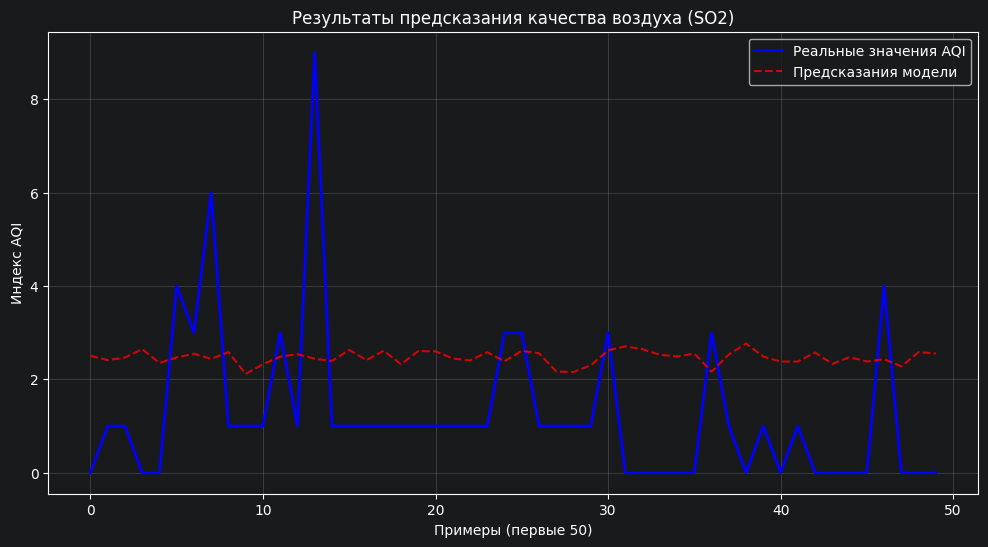

Средняя ошибка (MAE): 3.79
Точность (R2 score): -0.00


In [22]:
# 1. Очищаем валидационные данные от NaN, чтобы линия не рвалась
y_valid_clean = y_valid.dropna()
common_idx = final_X_valid.index.intersection(y_valid_clean.index)

X_val_final = final_X_valid.loc[common_idx]
y_val_final = y_valid_clean.loc[common_idx]

# 2. Делаем предсказание заново на чистых данных
preds = model.predict(X_val_final)

# 3. Рисуем красивый график
plt.figure(figsize=(12, 6))
# Используем .values, чтобы сбросить индексы для отрисовки от 0 до 50
plt.plot(y_val_final.values[:50], label='Реальные значения AQI', color='blue', linewidth=2)
plt.plot(preds[:50], label='Предсказания модели', color='red', linestyle='--', alpha=0.8)

plt.title('Результаты предсказания качества воздуха (SO2)')
plt.xlabel('Примеры (первые 50)')
plt.ylabel('Индекс AQI')
plt.legend()
plt.grid(True, alpha=0.3) # Добавим сетку для удобства
plt.show()

from sklearn.metrics import mean_absolute_error, r2_score

# Считаем показатели
mae = mean_absolute_error(y_val_final, preds)
r2 = r2_score(y_val_final, preds)

print(f"Средняя ошибка (MAE): {mae:.2f}")
print(f"Точность (R2 score): {r2:.2f}")